# Cats vs Dogs Image Classification using CNN

This project implements a Convolutional Neural Network (CNN) using PyTorch to classify images of cats and dogs.

The project covers:
- Data preprocessing and augmentation
- CNN model building
- Model training and validation
- Early stopping
- Model evaluation
- Performance visualization

Final Test Accuracy Achieved: **90.66%**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Dataset directory containing 'Cat' and 'Dog' folders
dataset_path = r"C:\Users\GOURI\Downloads\PetImages"

train_transform= transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))                       
])

dataset= ImageFolder(root= dataset_path) 

print("Total images: ", (len(dataset)))
print("Classes:", dataset.classes)

Total images:  24998
Classes: ['Cat', 'Dog']


In [5]:
train_size = int(0.65 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

trainset, valset, testset = random_split(
    dataset, [train_size, val_size, test_size]
)

In [6]:
trainset.dataset.transform = train_transform
valset.dataset.transform = test_transform
testset.dataset.transform = test_transform

In [7]:
trainset
print(len(trainset))

16248


In [8]:
valset
print(len(valset))

3749


In [9]:
testset
print(len(testset))

5001


In [10]:
print(len(trainset) + len(valset) + len(testset))

24998


In [11]:
trainloader= DataLoader(trainset, batch_size= 64, shuffle= True)
valloader= DataLoader(valset, batch_size= 64, shuffle= False)
testloader= DataLoader(testset, batch_size= 64, shuffle= False)

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers= nn.Sequential(
            nn.Conv2d(3, 32, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size= 3, padding= 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.fc_layers= nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x= self.conv_layers(x)
        x= x.view(x.size(0), -1)
        x= self.fc_layers(x)

        return x

In [13]:
model= CNN().to(device)
criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(model.parameters(), lr= 0.001)

In [15]:
train_losses= []
val_losses= []

epochs= 30

best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(epochs):
    epoch_training_loss= 0.0
    correct_train = 0
    total_train = 0

    model.train()

    # TRAINING:-
    for images, labels in trainloader:
        images= images.to(device)
        labels= labels.to(device)
        
        optimizer.zero_grad()

        outputs= model(images)
        loss= criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_training_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()


    train_loss = epoch_training_loss / len(trainloader)
    train_accuracy = 100 * correct_train / total_train
    
    train_losses.append(train_loss)

    # VALIDATION:-
    val_loss= 0.0
    correct= 0
    total= 0
    
    model.eval()
    
    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(valloader)
    val_losses.append(val_loss)

    val_accuracy = 100 * correct / total

    print(f"Epoch= {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

C:\Users\GOURI\anaconda3\envs\ml_env\lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch= 1/30 | Train Loss: 0.6077 | Train Acc: 66.57% | Val Loss: 0.5285 | Val Acc: 73.17%
Epoch= 2/30 | Train Loss: 0.5031 | Train Acc: 75.41% | Val Loss: 0.4328 | Val Acc: 80.29%
Epoch= 3/30 | Train Loss: 0.4462 | Train Acc: 79.39% | Val Loss: 0.4323 | Val Acc: 79.75%
Epoch= 4/30 | Train Loss: 0.4225 | Train Acc: 81.13% | Val Loss: 0.3850 | Val Acc: 82.85%
Epoch= 5/30 | Train Loss: 0.3886 | Train Acc: 83.03% | Val Loss: 0.4037 | Val Acc: 80.71%
Epoch= 6/30 | Train Loss: 0.3675 | Train Acc: 84.07% | Val Loss: 0.3424 | Val Acc: 85.30%
Epoch= 7/30 | Train Loss: 0.3480 | Train Acc: 85.21% | Val Loss: 0.3588 | Val Acc: 84.18%
Epoch= 8/30 | Train Loss: 0.3357 | Train Acc: 85.52% | Val Loss: 0.3276 | Val Acc: 85.52%
Epoch= 9/30 | Train Loss: 0.3159 | Train Acc: 86.68% | Val Loss: 0.3423 | Val Acc: 85.86%
Epoch= 10/30 | Train Loss: 0.3024 | Train Acc: 87.27% | Val Loss: 0.4386 | Val Acc: 81.60%
Epoch= 11/30 | Train Loss: 0.2906 | Train Acc: 87.56% | Val Loss: 0.3322 | Val Acc: 85.25%
Epoch= 1

In [16]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss
}, "best_model.pth")

In [17]:
checkpoint = torch.load("best_model.pth", map_location=device)

model = CNN().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

C:\Users\GOURI\AppData\Local\Temp\ipykernel_12516\856190545.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth", map_location=device

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Drop

In [18]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images= images.to(device)
        labels= labels.to(device)

        outputs= model(images)
        _, predicted= torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(all_labels, all_predictions,  target_names=dataset.classes))

Test Accuracy: 90.66%

Confusion Matrix:
 [[2273  233]
 [ 234 2261]]

Classification Report:
               precision    recall  f1-score   support

         Cat       0.91      0.91      0.91      2506
         Dog       0.91      0.91      0.91      2495

    accuracy                           0.91      5001
   macro avg       0.91      0.91      0.91      5001
weighted avg       0.91      0.91      0.91      5001



# Training vs Validation Loss Curve

The loss curves below help visualize the learning behavior of the model during training and validation.

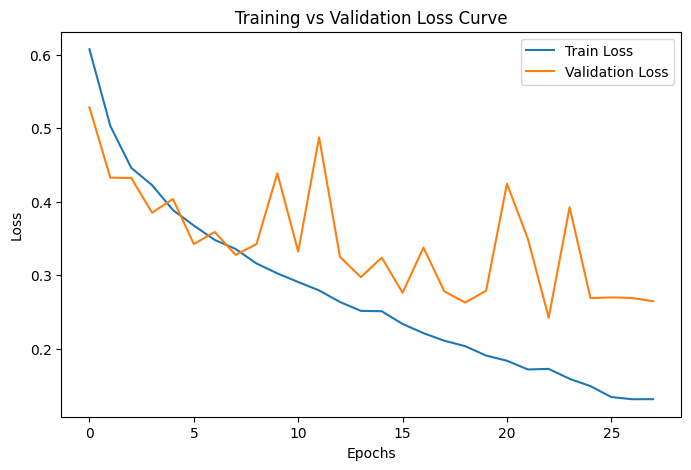

In [19]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")

plt.legend()
plt.show()

# Conclusion

The CNN model achieved strong performance on the Cats vs Dogs classification task with a final test accuracy of **90.66%**.

The project demonstrates an end-to-end deep learning workflow including preprocessing, model building, training, evaluation, and visualization using PyTorch.